https://www.kaggle.com/code/gowrishankarp/what-drives-student-exam-scores/notebook


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('student_performance_dataset.csv')

In [3]:
#Shape of the DataFrame
print('Shape of the DataFrame')
print(df.shape[0], 'Rows x', df.shape[1], 'Columns')

#Storing columns in a dictionary
data_info = {
    'dtype' : df.dtypes.astype(str),
    'unique' : df.nunique(),
    'null_values' : df.isnull().sum(),
    'null_pct' : (df.isnull().sum()/df.shape[0])*100,
    'constant' : df.nunique() <= 1
}

#Making a DataFrame
my_info = pd.DataFrame(data_info)

#Printing DataFrame
print(my_info)
#Finding duplicate instances
print(df.duplicated().sum(), 'duplicate instances')

Shape of the DataFrame
1000 Rows x 12 Columns
                              dtype  unique  null_values  null_pct  constant
student_id                    int64    1000            0       0.0     False
gender                          str       2            0       0.0     False
study_time_hours            float64      70            0       0.0     False
attendance_percent          float64     327            0       0.0     False
sleep_hours                 float64      65            0       0.0     False
parental_education              str       4          102      10.2     False
internet_access                 str       2            0       0.0     False
extracurricular_activities      str       2            0       0.0     False
part_time_job                   str       2            0       0.0     False
previous_grade              float64     434            0       0.0     False
final_exam_score            float64     342            0       0.0     False
final_grade                   

In [4]:
#Imputing parental education using mode
df['parental_education'] = df['parental_education'].fillna(df['parental_education'].mode()[0])

In [5]:
#Fetching numerical and categorical column lists for further data exploration
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()

In [6]:
#Observing correlation between numerical columns
df[numerical].corr()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
student_id,1.000000,0.027615,-0.044651,-0.012304,0.011917,0.025282
study_time_hours,0.027615,1.000000,-0.043712,0.005594,-0.035700,0.567513
attendance_percent,-0.044651,-0.043712,1.000000,0.034089,-0.014310,0.261872
sleep_hours,-0.012304,0.005594,0.034089,1.000000,0.000943,0.147811
previous_grade,0.011917,-0.035700,-0.014310,0.000943,1.000000,0.406327
final_exam_score,0.025282,0.567513,0.261872,0.147811,0.406327,1.000000


In [7]:
#Check for overlap between final_grade and final_exam_score
leak = df.groupby('final_grade')['final_exam_score'].agg(['min', 'max', 'mean', 'count']).sort_values('min')

leak.index

leak['prev_max'] = leak['max'].shift(1)
leak['is_overlap'] = leak['prev_max'] >= leak['max']

leak

,min,max,mean,count,prev_max,is_overlap
final_grade,,,,,,
F,46.8,59.7,56.675000,12,NaN,False
D,60.0,69.9,66.228090,89,59.7,False
C,70.0,79.9,75.413410,261,69.9,False
B,80.0,89.9,84.752825,354,79.9,False
A,90.0,100.0,96.069366,284,89.9,False


In [8]:
##Data Visualization Part

<Axes: xlabel='gender'>

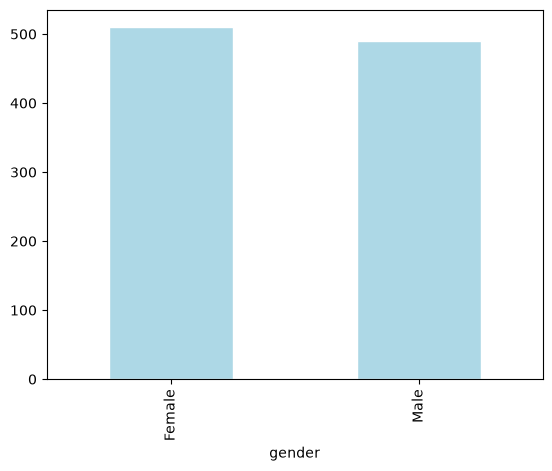

In [9]:
df['gender'].value_counts().plot(kind='bar', color='lightblue', edgecolor='white')

<Axes: xlabel='part_time_job'>

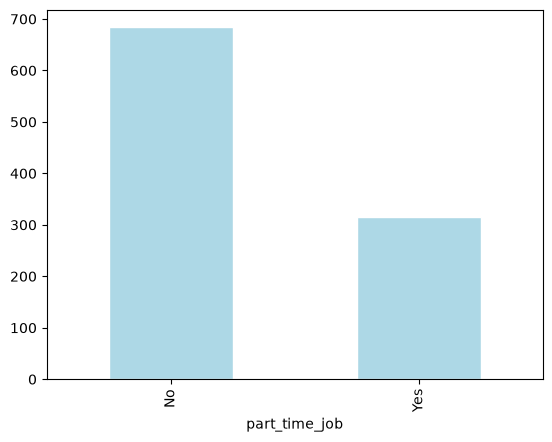

In [10]:
df['part_time_job'].value_counts().plot(kind='bar', color='lightblue', edgecolor='white' )

<Axes: xlabel='parental_education'>

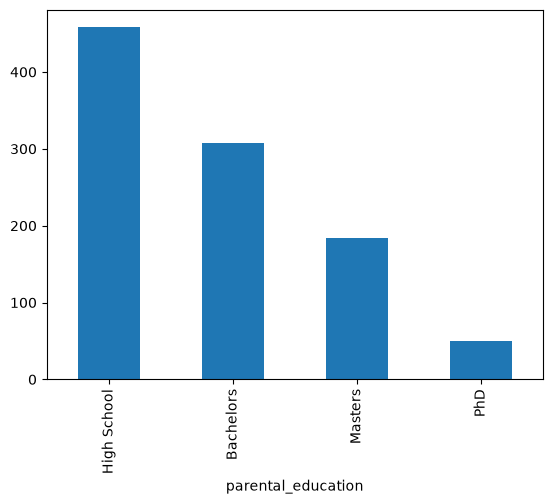

In [11]:
df['parental_education'].value_counts().plot(kind='bar')

<Axes: xlabel='internet_access'>

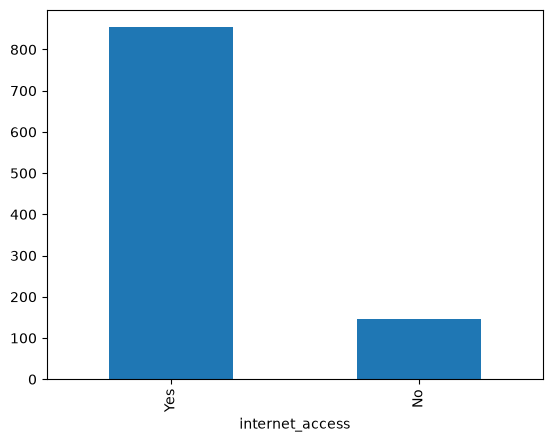

In [12]:
df['internet_access'].value_counts().plot(kind='bar')

In [13]:
df['internet_access'] = df['internet_access'].map({'Yes':1, 'No':0})

<Axes: xlabel='extracurricular_activities'>

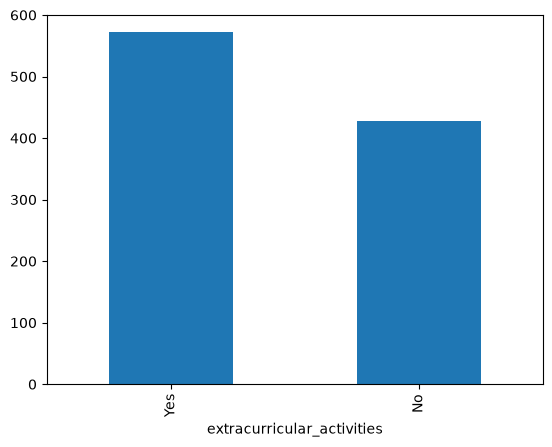

In [14]:
df['extracurricular_activities'].value_counts().plot(kind='bar')

In [15]:
df['extracurricular_activities'] = df['extracurricular_activities'].map({'Yes':1, 'No':0})

In [16]:
#Checking the data frame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          1000 non-null   str    
 6   internet_access             1000 non-null   int64  
 7   extracurricular_activities  1000 non-null   int64  
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   str    
dtypes: float64(5), int64(3), str(4)
memory usage: 93.9 KB


<Axes: xlabel='part_time_job'>

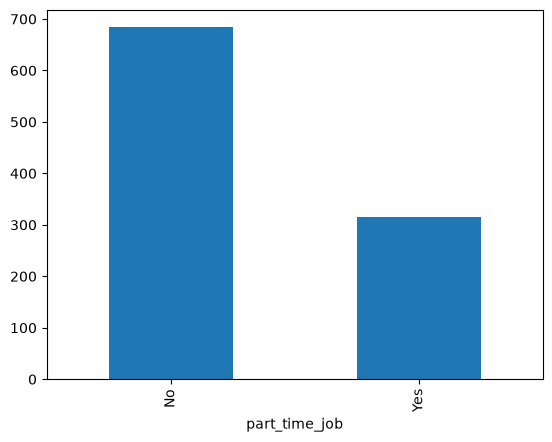

In [17]:
df['part_time_job'].value_counts().plot(kind='bar')

In [18]:
df['part_time_job'] = df['part_time_job'].map({'Yes':1, 'No':0})

<Axes: ylabel='Frequency'>

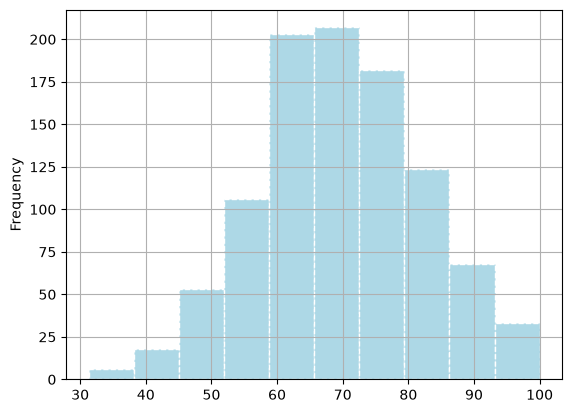

In [19]:
df['previous_grade'].plot(kind='hist', color='lightblue', edgecolor='white', linestyle='--', grid=True)

<Axes: xlabel='final_grade'>

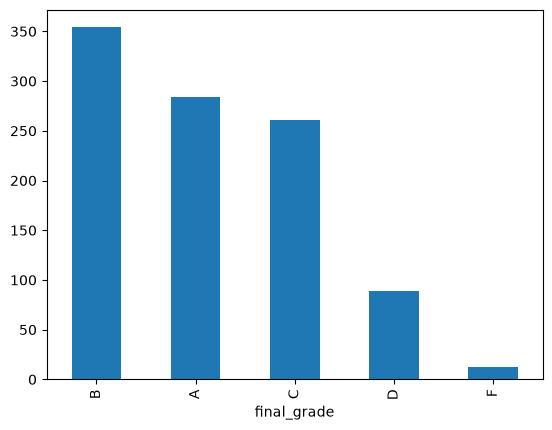

In [20]:
df['final_grade'].value_counts().plot(kind='bar')

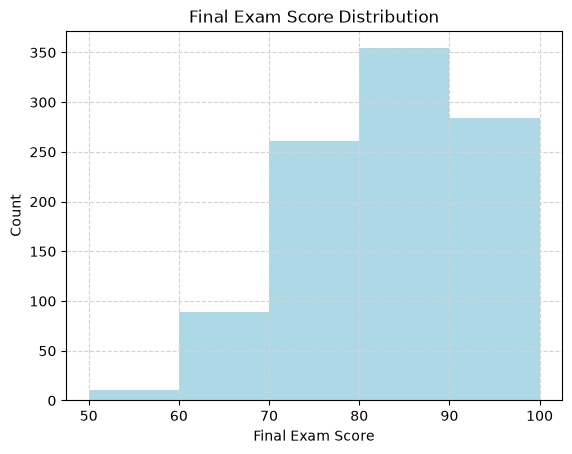

In [21]:
plt.hist(df['final_exam_score'], bins = [50,60,70,80,90,100], color='lightblue')
plt.grid(True, linestyle='--', color='lightgray')
plt.title('Final Exam Score Distribution')
plt.xlabel('Final Exam Score')
plt.ylabel('Count')

plt.show()

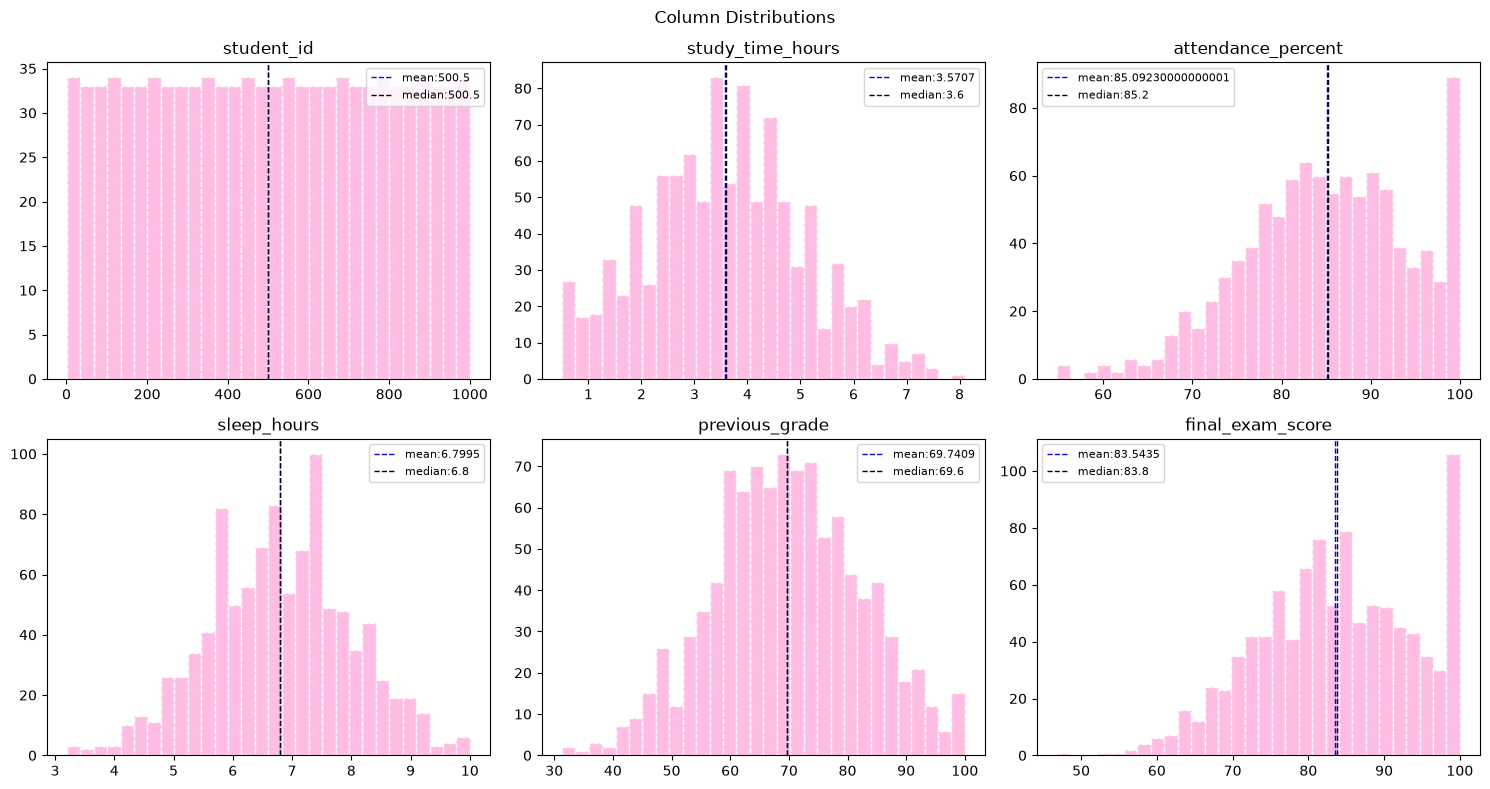

In [22]:
#Implementing subplots for Data Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numerical):
  ax.hist(df[col], bins=30, color='#FFBDE3', edgecolor='white', linestyle='--')
  ax.axvline(df[col].mean(),color='blue', linestyle='--', linewidth=1, label=f'mean:{df[col].mean()}')
  ax.axvline(df[col].median(),color='black', linestyle='--', linewidth=1, label=f'median:{df[col].median()}')
  ax.set_title(col)
  ax.legend(fontsize=8)

plt.suptitle('Column Distributions')
plt.tight_layout()
plt.show()

C:\Users\Akash\AppData\Local\Temp\ipykernel_3896\742337515.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\Akash\AppData\Local\Temp\ipykernel_3896\742337515.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\Akash\AppData\Local\Temp\ipykernel_3896\742337515.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
C:\Users\Akash\AppData\Local\Temp\ipykernel_3896\742337515.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called wi

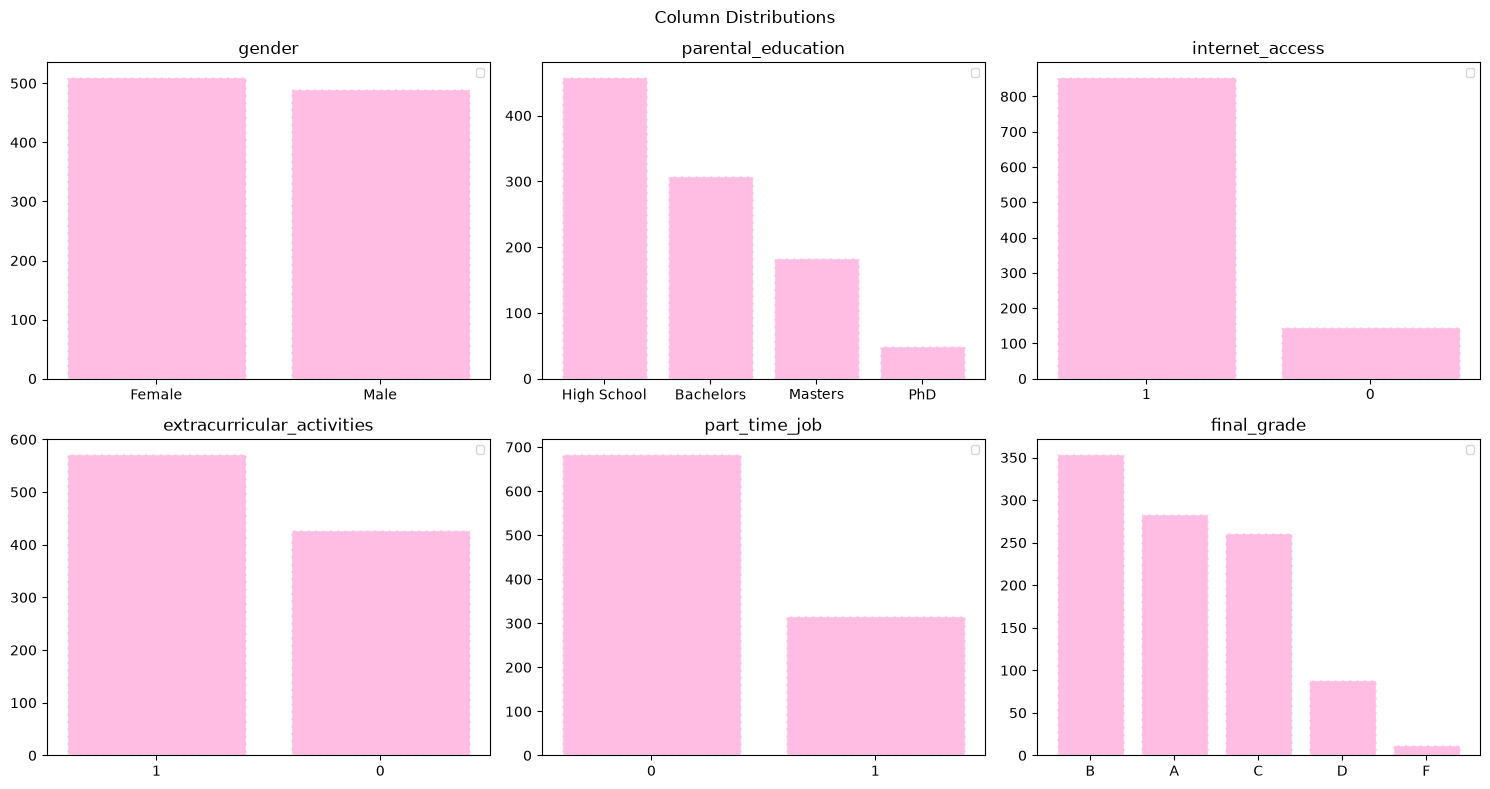

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, categorical):

  vc = df[col].value_counts()
  ax.bar(vc.index.astype('str'), vc.values, color='#FFBDE3', edgecolor='white', linestyle='--')

  ax.set_title(col)
  ax.legend(fontsize=8)

plt.suptitle('Column Distributions')
plt.tight_layout()
plt.show()